In [1]:
from agrifoodpy_data.land import UKCEH_LC_1000
from agrifoodpy_data.food import FAOSTAT
from agrifoodpy import land, food
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from utils import da_to_map, da_to_gpd
import geopandas as gpd

# Self-sufficiency ratio in different local authorities in the UK
In this notebook we estimate the self-sufficiency ratio (SSR) as a function of local authority (LA) specific quantities, under a series of assumptions regarding production and domestic use.

Here we define SSR as $SSR =  \frac{P}{D} = \frac{P}{Fo+Pr+Lo+Fe+Se+To}$,

Where $P$ represents the total production of all food commodities and $D$ is the total domestic use.
Domestic use is the sum of the following food uses:
- $Fo$: Food for human consumption, measured from the Retail stage
- $Pr$: Processing quantities, which is food used for the processing of other foods
- $Lo$: Losses at the production stage
- $Fe$: Animal feed for livestock farming
- $Se$: Seeds for arable farming
- $To$: Tourist consumption
  

We start by loading the UK food use dataset from agrifoodpy-data.
Then we scale production based on the total arable and pasture land for each local autority and scale domestic use based on the changes to production and the total population for each local authority.

We then compute the resulting SSR values and map them.

In [2]:
land_use_uk = UKCEH_LC_1000["dominant_aggregate"]
LA_pop_arr = xr.load_dataarray("data/LA_pop_arr.nc")
LA_pop_map = xr.load_dataarray("data/LA_pop_map.nc")
LA_region_map = xr.load_dataarray("data/LA_region_map.nc")

In [3]:
LA_region_map

<xarray.DataArray 'Region' (y: 1300, x: 713)> Size: 4MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1300, 713), dtype=float32)
Coordinates:
  * y        (y) float64 10kB 500.0 1.5e+03 2.5e+03 ... 1.298e+06 1.3e+06
  * x        (x) float64 6kB 500.0 1.5e+03 2.5e+03 ... 7.115e+05 7.125e+05
Attributes: (12/217)
    Aberdeen City:                         0
    Aberdeenshire:                         1
    Angus:                                 2
    Antrim and Newtownabbey:               3
    Ards and North Down:                   4
    Argyll and Bute:                       5
    ...                                    ...
    Wirral:                                211
    Wokingham:                             212
    Wolverhampton:                         213
    Worcestershire:                        214
    Wrexham:                               215
    York:                                  216

Text(0.5, 1.0, 'Land Use')

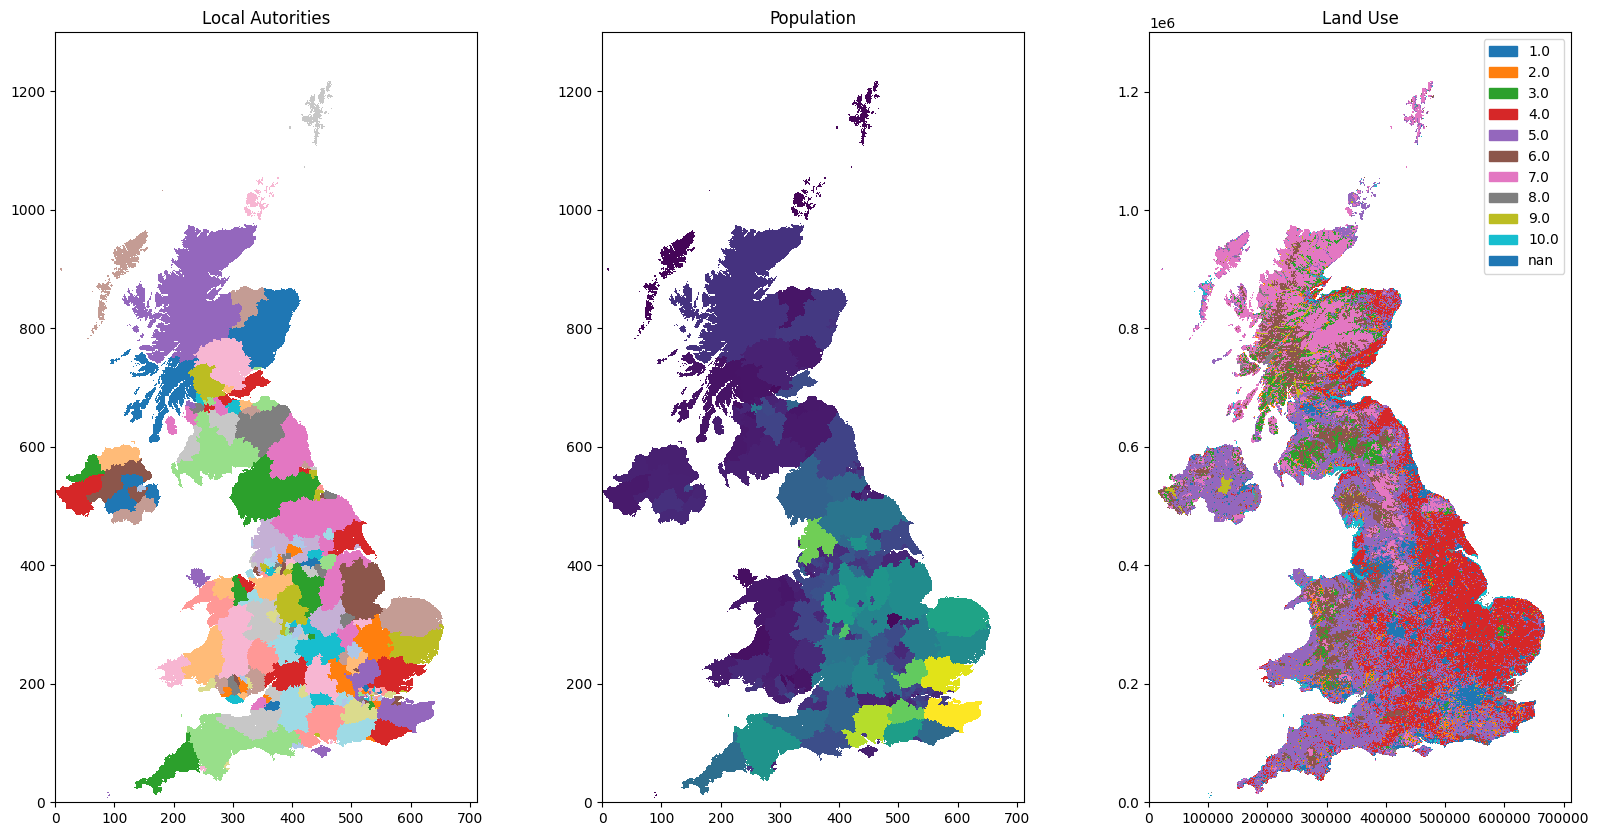

In [4]:
f, ax = plt.subplots(1, 3, figsize=(20, 10))
# LA_region_map.land.plot(ax=ax[0])
# LA_pop_map.land.plot(ax=ax[1])
# land_use_uk.land.plot(ax=ax[2])

ax[0].imshow(LA_region_map, interpolation='none', origin='lower', cmap='tab20')
ax[1].imshow(LA_pop_map, interpolation='none', origin='lower')
land_use_uk.land.plot(ax=ax[2])


ax[0].set_title("Local Autorities")
ax[1].set_title("Population")
ax[2].set_title("Land Use")

## Land use
Here we identify the total area of pasture and arable land in each LA and save it
as a segment map

Text(0.5, 1.0, 'Pasture land')

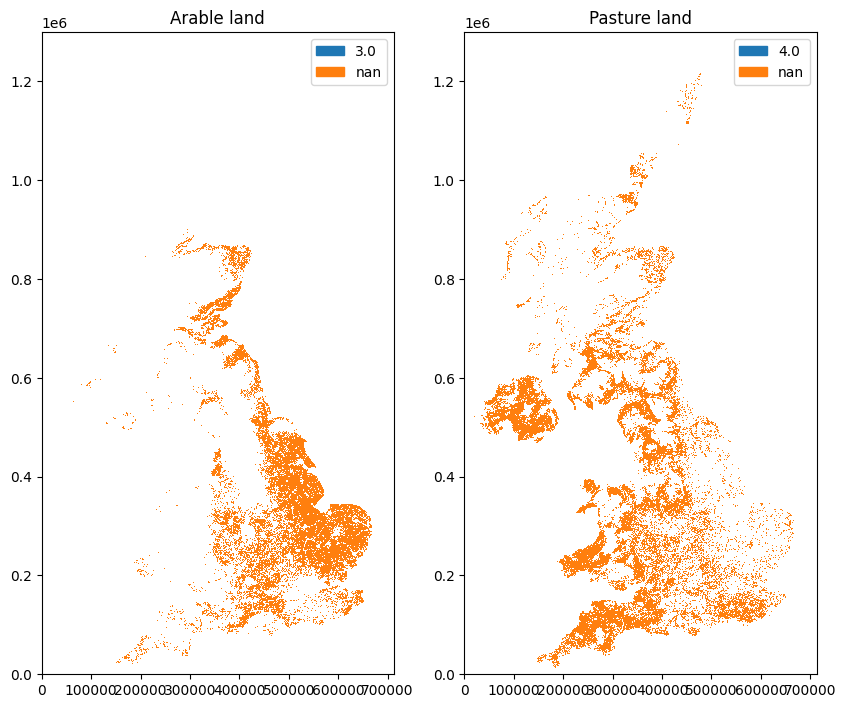

In [5]:
# Plot arable and pasture land use

f, ax = plt.subplots(1, 2, figsize=(10,10))

arable_uk = land_use_uk.where(land_use_uk == 3)
pasture_uk = land_use_uk.where(land_use_uk == 4)

arable_uk.land.plot(ax=ax[0])
pasture_uk.land.plot(ax=ax[1])

arable_total_area = arable_uk.land.area_by_type().values
pasture_total_area = pasture_uk.land.area_by_type().values
ax[0].set_title("Arable land")
ax[1].set_title("Pasture land")

In [6]:
# Calculate area of arable and pasture land per local authority

arable_area_la = LA_region_map.land.area_overlap(arable_uk)
arable_area_la = arable_area_la.squeeze(drop=True)
arable_area_la["Region"] = list(LA_region_map.attrs.keys())

pasture_area_la = LA_region_map.land.area_overlap(pasture_uk)
pasture_area_la = pasture_area_la.squeeze(drop=True)
pasture_area_la["Region"] = list(LA_region_map.attrs.keys())

In [7]:
# Calculate percentage of arable and pasture land per local authority, relative to the total UK area

arable_percentage_la = arable_area_la / arable_total_area * 100
pasture_percentage_la = pasture_area_la / pasture_total_area * 100

In [8]:
# Create maps of arable and pasture land percentage per local authority

arable_area_la_map = xr.zeros_like(LA_region_map)
pasture_area_la_map = xr.zeros_like(LA_region_map)

for namela, ila in LA_region_map.attrs.items():
    ila_mask = (LA_region_map != ila)

    arable_pct = xr.where(ila_mask, 0, arable_percentage_la.sel(Region=namela))
    pasture_pct = xr.where(ila_mask, 0, pasture_percentage_la.sel(Region=namela))
    
    arable_area_la_map += arable_pct.squeeze(drop=True)
    pasture_area_la_map += pasture_pct.squeeze(drop=True)

arable_area_la_map = arable_area_la_map.where(LA_region_map > 0)
pasture_area_la_map = pasture_area_la_map.where(LA_region_map > 0)


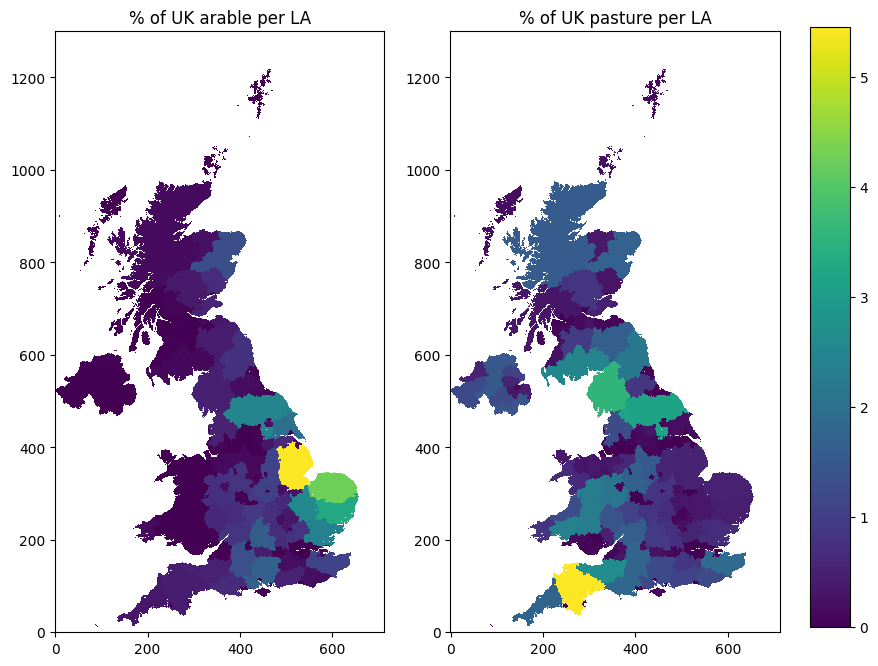

In [9]:

f, ax = plt.subplots(1, 2, figsize=(10, 10))
# arable_area_la_map.land.plot(ax=ax[0])
# pasture_area_la_map.land.plot(ax=ax[1])
ax[0].imshow(arable_area_la_map, interpolation='none', origin='lower')
im1=ax[1].imshow(pasture_area_la_map, interpolation='none', origin='lower')

ax[0].set_title("% of UK arable per LA")
ax[1].set_title("% of UK pasture per LA")

# add space for colour bar
f.subplots_adjust(right=0.85)
cbar_ax = f.add_axes([0.88, 0.2, 0.04, 0.6])
f.colorbar(im1, cax=cbar_ax)

# The chart on the left is the percentage of the total UK arable land that is located within each local authority.
# The chart on the right is the percentage of the total UK pasture land that is located within each local authority.

## Food production
We create a food balance sheet object for each LA by scaling the total production according to the land use percentages we found above

In [10]:
# Load food data for the UK in 2019
food_uk = FAOSTAT.sel(Year=2019, Region=229).squeeze(drop=True)
food_uk *= 1
food_uk.Item_group.values = np.array(food_uk.Item_group.values, dtype=str)
food_uk.Item_origin.values = np.array(food_uk.Item_origin.values, dtype=str)
food_uk.Item_name.values = np.array(food_uk.Item_name.values, dtype=str)
food_uk.Region_name.values = np.array(food_uk.Region_name.values, dtype=str)
food_uk

<xarray.Dataset> Size: 40kB
Dimensions:      (Item: 117)
Coordinates:
  * Item         (Item) int64 936B 2511 2513 2514 2515 ... 2948 2949 2960 2961
    Region       int64 8B 229
    Region_name  <U52 208B 'United Kingdom of Great Britain and Northern Irel...
    Year         int64 8B 2019
    Item_name    (Item) <U31 15kB 'Wheat and products' ... 'Aquatic Products,...
    Item_group   (Item) <U24 11kB 'Cereals - Excluding Beer' ... 'Aquatic Pro...
    Item_origin  (Item) <U16 7kB 'Vegetal Products' ... 'Animal Products'
Data variables: (12/13)
    stock        (Item) float32 468B 1.314e+03 511.0 201.0 0.0 ... 0.0 0.0 nan
    losses       (Item) float32 468B 81.0 40.0 28.0 2.0 5.0 ... 0.0 10.0 nan nan
    processing   (Item) float32 468B 335.0 1.504e+03 844.0 nan ... nan nan nan
    food         (Item) float32 468B 6.789e+03 214.0 470.0 ... 1.216e+03 0.0
    other        (Item) float32 468B 773.0 nan 477.0 nan ... 0.0 0.0 1.21 4.85
    residual     (Item) float32 468B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 nan nan
    ...           ...
    domestic     (Item) float32 468B 1.572e+04 5.74e+03 ... 1.588e+03 4.85
    production   (Item) float32 468B 1.622e+04 8.048e+03 0.0 ... 805.0 846.8 0.0
    feed         (Item) float32 468B 7.459e+03 3.795e+03 729.0 ... nan 370.0 nan
    seed         (Item) float32 468B 281.0 187.0 nan 3.0 ... nan 90.0 nan nan
    imports      (Item) float32 468B 2.521e+03 142.0 ... 1.723e+03 8.17
    exports      (Item) float32 468B 1.714e+03 1.939e+03 178.0 ... 982.5 3.32

In [11]:
food_uk = food_uk.drop_vars(["Region", "Region_name", "Year"])

In [12]:
food_la = food_uk.copy(deep=True)
food_la = food_la.expand_dims({'Region': LA_pop_arr["Region"].values})
food_la = food_la.assign_coords({"Region":np.array(food_la.Region.values, dtype=str)})
food_la = food_la.drop_vars(["domestic", "imports", "exports"])
food_la = food_la.sortby("Region")

In [13]:
# Scale plant production in terms of LA arable land
plant_items = food_uk.Item.loc[food_uk.Item_origin == 'Vegetal Products'].values
arable_percentage_la = arable_percentage_la.squeeze(drop=True)
arable_percentage_la_expanded_plant = arable_percentage_la.expand_dims({"Item": len(plant_items)})

scaled_data = food_uk.production.loc[{"Item": plant_items}] * arable_percentage_la_expanded_plant / 100
food_la.production.loc[{"Item":plant_items}] = scaled_data

In [14]:
# Scale seed use in terms of LA arable land
food_la["seed"] *= arable_percentage_la / 100
food_la["feed"] *= pasture_percentage_la / 100

In [15]:
# Scale rest of animal production in terms of LA pasture land
animal_items = food_uk.Item.loc[food_uk.Item_origin == 'Animal Products'].values
pasture_percentage_la = pasture_percentage_la.squeeze(drop=True)
pasture_percentage_la_expanded_animal = pasture_percentage_la.expand_dims({"Item": len(animal_items)})

scaled_data = food_uk.production.loc[{"Item": animal_items}] * pasture_percentage_la_expanded_animal / 100
food_la.production.loc[{"Item":animal_items}] = scaled_data

In [16]:
# Test for a single local authority
pasture_percentage_la.sel(Region='Orkney Islands')

<xarray.DataArray ()> Size: 4B
array(0.2183324, dtype=float32)
Coordinates:
    Region   <U36 144B 'Orkney Islands'

<Axes: >

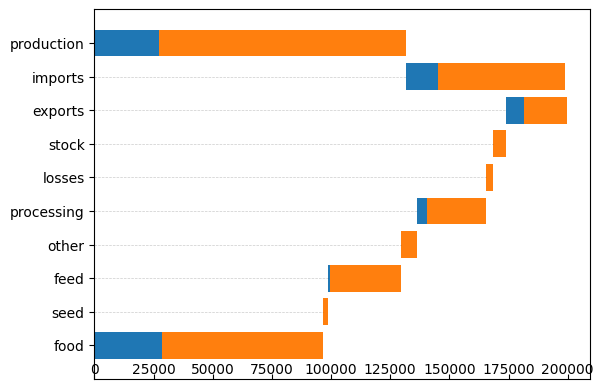

In [17]:
food_uk_origin = food_uk.fbs.group_sum("Item_origin")
food_uk_origin.fbs.plot_bars(show="Item_origin",
                             elements=["production", "imports"],
                             inverted_elements=["exports", "stock", "losses", "processing", "other", "feed", "seed", "food"])

# Scale elements dependent on population

In [18]:
# Scale food, tourist consumption, and stock in terms of population

pop_elements = ["food", "tourist", "stock"]
population_LA_percentage = LA_pop_arr / LA_pop_arr.sum()

food_la[pop_elements] = food_uk[pop_elements] * population_LA_percentage

# Scale elements dependent on production

In [19]:
# Scale processing
food_la["processing"] = food_uk["processing"] * food_la["production"] / food_uk["production"]

In [20]:
# Scale losses
food_la["losses"] = food_uk["losses"] * food_la["production"] / food_uk["production"]

# Prepare and visualise the results

<Axes: >

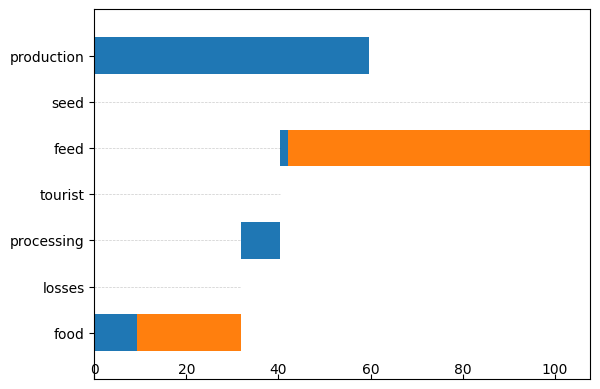

In [21]:
food_la["domestic"] = food_la["seed"].fillna(0) + food_la["feed"].fillna(0) + food_la["tourist"].fillna(0) + food_la["processing"].fillna(0) + food_la["losses"].fillna(0) + food_la["food"].fillna(0)

food_la_origin = food_la.fbs.group_sum("Item_origin")
food_la_origin.sel(Region="Orkney Islands").fbs.plot_bars(show="Item_origin",
                                                 elements=["production"],
                                                 inverted_elements=["seed", "feed", "tourist", "processing", "losses", "food"])

In [22]:
food_la_origin.sel(Region="Orkney Islands")

<xarray.Dataset> Size: 280B
Dimensions:      (Item_origin: 2)
Coordinates:
  * Item_origin  (Item_origin) object 16B 'Animal Products' 'Vegetal Products'
    Region       <U36 144B 'Orkney Islands'
Data variables:
    stock        (Item_origin) float64 16B -0.03418 1.785
    losses       (Item_origin) float32 8B 0.1004 0.0
    processing   (Item_origin) float32 8B 8.43 0.0
    food         (Item_origin) float64 16B 9.345 22.43
    other        (Item_origin) float32 8B 151.0 6.858e+03
    residual     (Item_origin) float32 8B -22.0 -570.0
    tourist      (Item_origin) float64 16B 0.0 0.0
    production   (Item_origin) float32 8B 59.58 0.0
    feed         (Item_origin) float32 8B 1.748 65.76
    seed         (Item_origin) float32 8B 0.0 0.0
    domestic     (Item_origin) float64 16B 19.62 88.19

<Axes: >

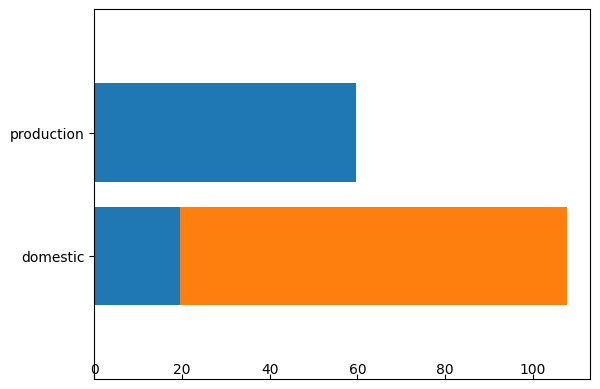

In [23]:
food_la_origin = food_la.fbs.group_sum("Item_origin")
food_la_origin.sel(Region="Orkney Islands").fbs.plot_bars(show="Item_origin",
                                                 elements=["production"],
                                                 inverted_elements=["domestic"])

In [24]:
food_la

<xarray.Dataset> Size: 2MB
Dimensions:      (Item: 117, Region: 217)
Coordinates:
  * Item         (Item) int64 936B 2511 2513 2514 2515 ... 2948 2949 2960 2961
  * Region       (Region) <U36 31kB 'Aberdeen City' 'Aberdeenshire' ... 'York'
    Item_name    (Item) <U31 15kB 'Wheat and products' ... 'Aquatic Products,...
    Item_group   (Item) <U24 11kB 'Cereals - Excluding Beer' ... 'Aquatic Pro...
    Item_origin  (Item) <U16 7kB 'Vegetal Products' ... 'Animal Products'
Data variables:
    stock        (Item, Region) float64 203kB 4.397 5.18 2.246 ... nan nan nan
    losses       (Item, Region) float32 102kB 0.09811 1.716 0.9079 ... nan nan
    processing   (Item, Region) float32 102kB 0.4058 7.098 3.755 ... nan nan nan
    food         (Item, Region) float64 203kB 22.72 26.77 11.6 ... 0.0 0.0 0.0
    other        (Region, Item) float32 102kB 773.0 nan 477.0 ... 0.0 1.21 4.85
    residual     (Region, Item) float32 102kB 0.0 0.0 0.0 0.0 ... 0.0 nan nan
    tourist      (Item, Region) float64 203kB nan nan nan nan ... nan nan nan
    production   (Region, Item) float32 102kB 19.65 9.748 0.0 ... 0.5632 0.0
    feed         (Region, Item) float32 102kB 5.803 2.952 0.5671 ... 0.2461 nan
    seed         (Region, Item) float32 102kB 0.3404 0.2265 nan ... nan nan
    domestic     (Region, Item) float64 203kB 29.37 5.765 2.14 ... 3.929 0.0

In [25]:
LA_ssr_arr = food_la["production"].sum(dim="Item") / food_la["domestic"].sum(dim="Item")
LA_ssr_arr.name = "SSR"
LA_ssr_arr

<xarray.DataArray 'SSR' (Region: 217)> Size: 2kB
array([3.84482029e-01, 1.70670004e+00, 2.15092790e+00, 3.75973979e-01,
       4.28180280e-01, 4.52222639e-01, 4.74926173e-01, 2.16078561e-03,
       1.37614590e-02, 1.82683154e-01, 3.10326675e-01, 1.38932082e+00,
       7.28496009e-02, 9.60870208e-04, 3.08192733e-02, 1.40647619e-01,
       0.00000000e+00, 1.04901332e-02, 1.45364549e-01, 1.01354893e-01,
       1.52922645e-01, 6.81487057e-02, 1.63964014e-02, 7.23109569e-02,
       8.17620993e-02, 2.93404214e-02, 8.52884194e-03, 1.01642718e+00,
       6.26784637e-02, 5.62871303e-02, 1.00095463e-01, 1.97237833e+00,
       3.37065138e-03, 7.79766724e-02, 5.99236676e-01, 6.70088708e-01,
       9.88819231e-01, 6.63708145e-01, 5.43343445e-01, 4.51915938e-01,
       2.61999595e-01, 0.00000000e+00, 1.10847077e+00, 3.07569272e-01,
       6.74914208e-01, 4.78756689e-01, 1.17407527e-01, 1.59805188e-02,
       8.18743137e-01, 1.00340005e+00, 3.95319190e-01, 1.22813025e-01,
       3.76492969e-01, 3.87696994e-01, 6.81896216e-01, 9.51377186e-01,
       1.09778550e+00, 2.18191750e-01, 7.68289806e-01, 2.47648718e-01,
       1.92925954e-02, 6.00858597e-01, 9.98745027e-02, 1.77344949e+00,
       2.77984025e-01, 2.33722565e+00, 5.09504447e-01, 7.66002534e-02,
       1.21408750e+00, 1.85530992e-01, 5.64682184e-01, 1.15336520e+00,
       3.43170149e-01, 2.33876009e-01, 6.93565927e-02, 9.82299085e-01,
       0.00000000e+00, 5.30877568e-01, 1.82573440e-03, 9.58695581e-03,
...
       1.06466786e+00, 3.46384185e-02, 5.52660198e-01, 1.41885768e+00,
       9.15324937e-01, 1.32133319e+00, 1.05567327e+00, 1.50801600e-01,
       4.42911033e-02, 6.38417581e-01, 1.01885501e-01, 7.63512295e-04,
       5.22341110e-01, 7.15132393e-02, 1.17447307e-01, 1.43051135e-02,
       6.42055738e-02, 1.19643742e-01, 1.80645527e+00, 6.73842915e-02,
       1.33397713e-01, 1.22963071e+00, 0.00000000e+00, 1.87153214e-02,
       4.47946751e-01, 1.20749053e+00, 6.51332240e-02, 8.52733109e-02,
       7.93416819e-01, 4.02193850e-01, 2.11429226e-01, 3.36813860e-01,
       2.13003806e-02, 2.13134204e-02, 7.03663601e-02, 4.59750560e-03,
       1.43602643e-01, 8.37336937e-01, 7.56781874e-01, 2.98638741e-02,
       6.43209243e-01, 1.26935060e-01, 2.07776132e+00, 2.11139306e-01,
       2.65177495e-01, 1.44331910e-02, 1.19441968e-01, 2.31626427e-01,
       0.00000000e+00, 9.70206161e-01, 1.73408865e-01, 1.03195947e-01,
       4.13774914e-02, 0.00000000e+00, 1.31768511e-01, 5.12882377e-01,
       2.78094823e-01, 1.29335564e-01, 4.23517839e-03, 1.44535362e-03,
       2.52537978e-01, 1.13401224e+00, 1.53925101e+00, 6.85361771e-02,
       2.61081126e-01, 1.22428908e+00, 6.35167934e-01, 4.61664582e-03,
       3.97432069e-01, 1.39965068e+00, 4.40842602e-01, 1.92312224e-02,
       3.47158072e-01, 2.50701180e-01, 9.40497592e-01, 2.75223681e-01,
       9.23410698e-01])
Coordinates:
  * Region   (Region) <U36 31kB 'Aberdeen City' 'Aberdeenshire' ... 'York'

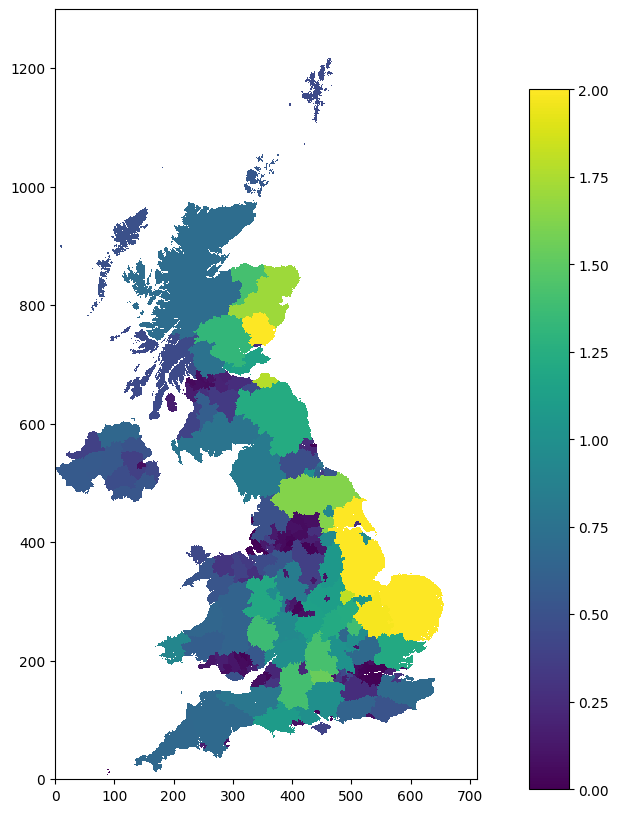

In [26]:
f, ax = plt.subplots(figsize=(10, 10))
LA_ssr_map = da_to_map(LA_ssr_arr, LA_region_map)
# LA_ssr_map.land.plot(ax=ax)
im = ax.imshow(LA_ssr_map, interpolation='none', origin='lower', vmin=0, vmax=2, cmap='viridis')

# add space for colour bar
f.subplots_adjust(right=0.85)
cbar_ax = f.add_axes([0.75, 0.1, 0.04, 0.7])
f.colorbar(im, cax=cbar_ax)

In [27]:
LA_map_uk = gpd.read_file("data/Counties_and_Unitary_Authorities_December_2021_UK_BGC_2022_-4194855654272946208.gpkg")
LA_map_uk = da_to_gpd(LA_ssr_arr, LA_map_uk, "Region", "CTYUA21NM")
LA_map_uk.head()

,CTYUA21CD,CTYUA21NM,CTYUA21NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,SSR
0,E06000001,Hartlepool,,447160,531474,-1.27018,54.676102,{1FEF44F1-C688-448F-8566-47B9AA169146},"MULTIPOLYGON (((447097.001 537152.001, 446953....",0.757615
1,E06000002,Middlesbrough,,451141,516887,-1.21099,54.544701,{9C23D16E-FD69-4C12-84E8-BD741DFF540C},"MULTIPOLYGON (((449862.75 521262.4, 449381.8 5...",0.328449
2,E06000003,Redcar and Cleveland,,464361,519597,-1.00608,54.567501,{9A564496-C9C6-40A4-817B-C992B89F643F},"MULTIPOLYGON (((455939.672 527395.073, 455853....",0.522341
3,E06000004,Stockton-on-Tees,,444940,518183,-1.30664,54.556900,{D225D558-7BF7-4F62-A4CD-B23004FE28E9},"MULTIPOLYGON (((444126.099 528005.799, 444064....",0.643209
4,E06000005,Darlington,,428029,515648,-1.56835,54.535301,{BB565C9E-E3DE-4997-98BE-0A72541B5E21},"MULTIPOLYGON (((423475.701 524731.597, 423296....",1.003400


<Axes: >

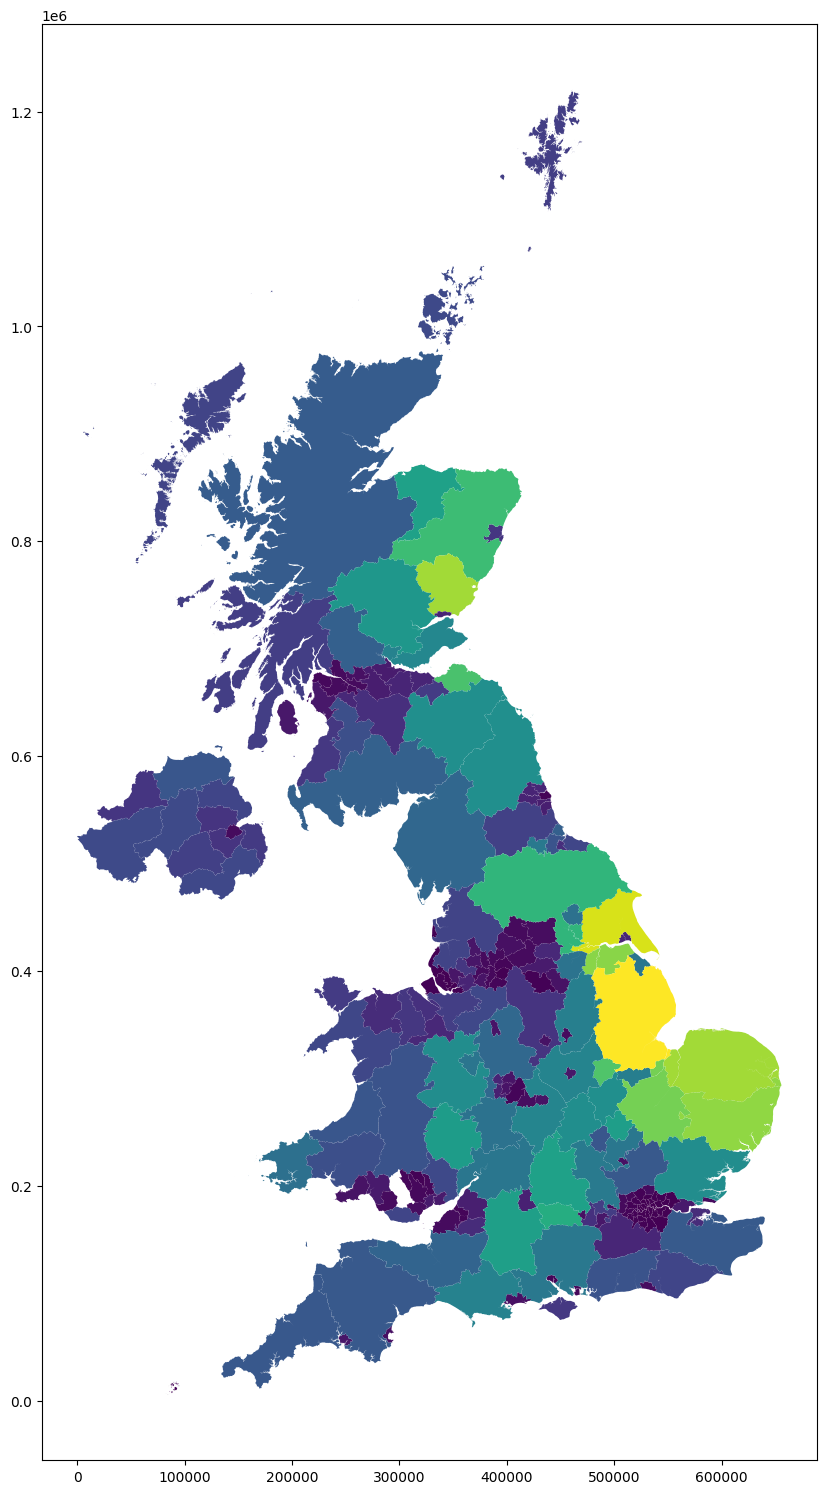

In [28]:
LA_map_uk.plot("SSR", figsize=(10,20)) 